In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshsingh2209/medical-insurance-payout")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medical-insurance-payout' dataset.
Path to dataset files: /kaggle/input/medical-insurance-payout


In [4]:
import pandas as pd
import os

# Assuming the dataset contains a CSV file, let's find it.
# You might need to adjust the filename if it's different.
# For example, if there are multiple CSVs, you might need to specify the correct one.

# List files in the downloaded path to identify the CSV file
print(f"Files in the dataset directory: {os.listdir(path)}")

# The file name was incorrect. Correcting to 'expenses.csv' based on the directory listing.
csv_file_path = os.path.join(path, 'expenses.csv')

df = pd.read_csv(csv_file_path)
display(df.head())

Files in the dataset directory: ['expenses.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# df.shape

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


<Axes: xlabel='smoker', ylabel='count'>

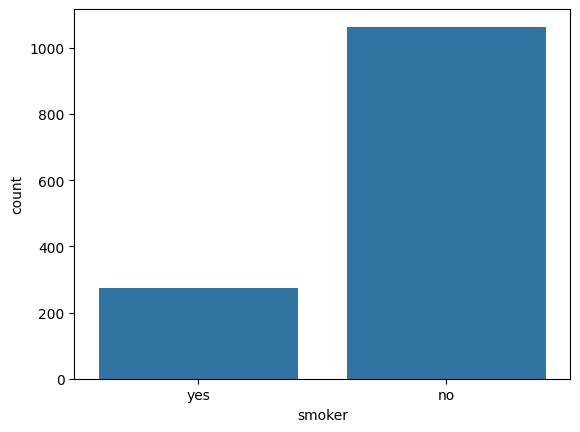

In [10]:
import seaborn as sns
sns.countplot(x=df['smoker'])

In [11]:
# class imbalance so we will correct it by log transformation and for numerical columns(dataset) skewness we will use SMOTE

In [12]:
# visualization
cat_col = df.select_dtypes(include="object").columns.tolist()
cat_col

['sex', 'smoker', 'region']

In [13]:
num_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
num_col

['age', 'bmi', 'children', 'charges']

In [14]:
df[cat_col].describe()

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [15]:
# cate = count/bar
# num = histo
# Category + Target(Category)  =  Countplot with hue
# Numerical + Target(Category) =  Boxplot
# Numerical + Numerical       =  Scatterplot

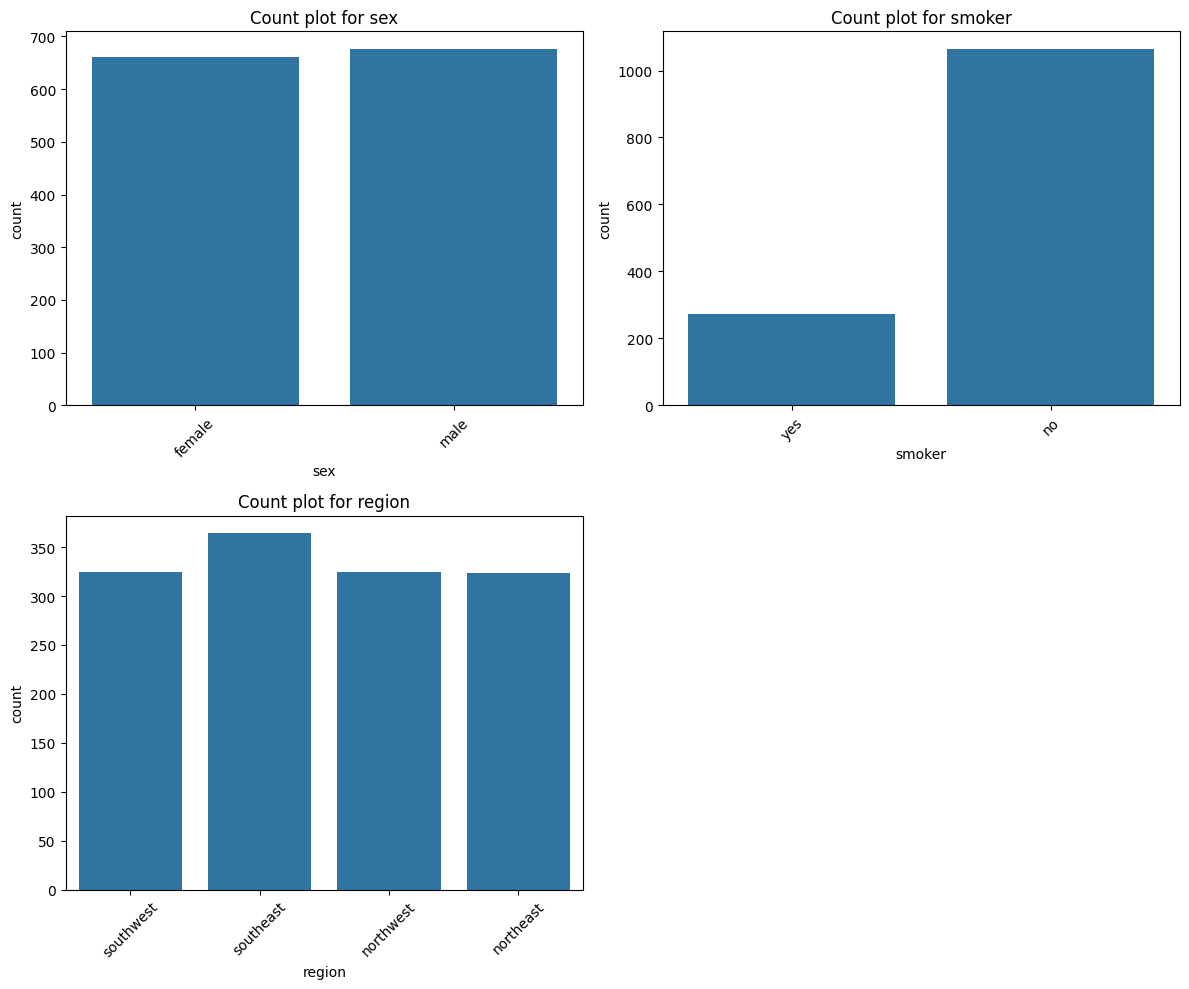

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # Create a 2x2 grid for subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(cat_col):
    sns.countplot(x=col, data=df, ax=axes[i]) # Plot on the current axis
    axes[i].set_title(f'Count plot for {col}') # Set title for each subplot
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(cat_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [17]:
num_col

['age', 'bmi', 'children', 'charges']

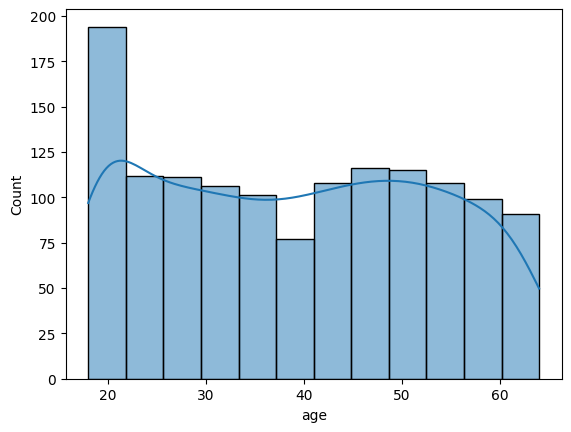

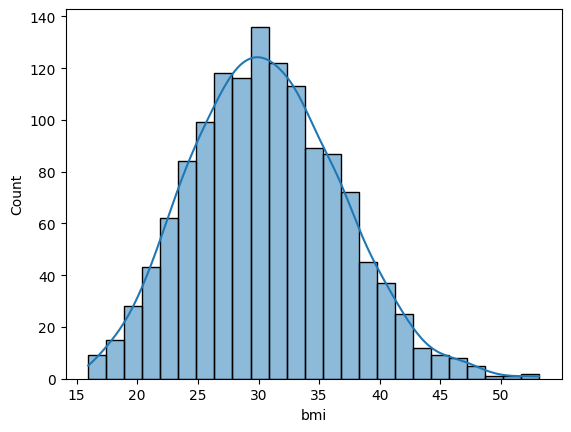

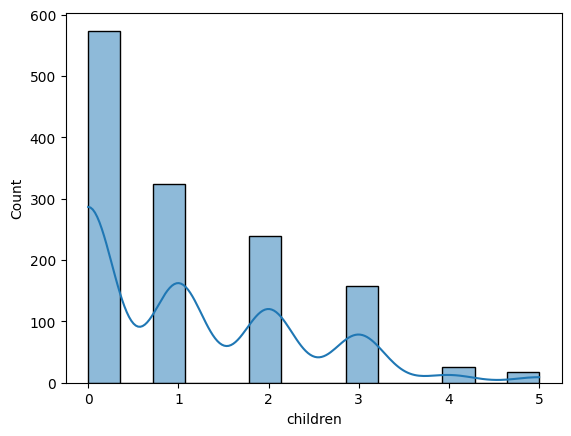

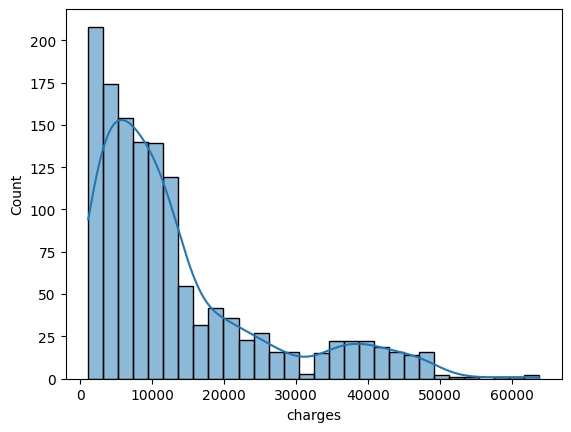

In [18]:
for i in num_col:
    sns.histplot(x=df[i], kde=True)
    plt.show()



<Axes: xlabel='age', ylabel='smoker'>

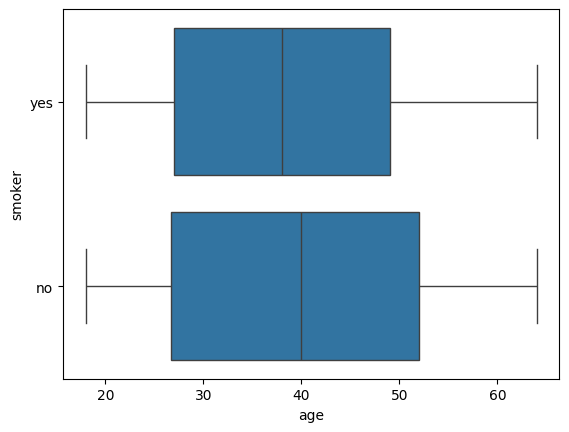

In [19]:
# numerical vs target
sns.boxplot(x=df["age"],y = df["smoker"],data = df)

<Axes: xlabel='bmi', ylabel='smoker'>

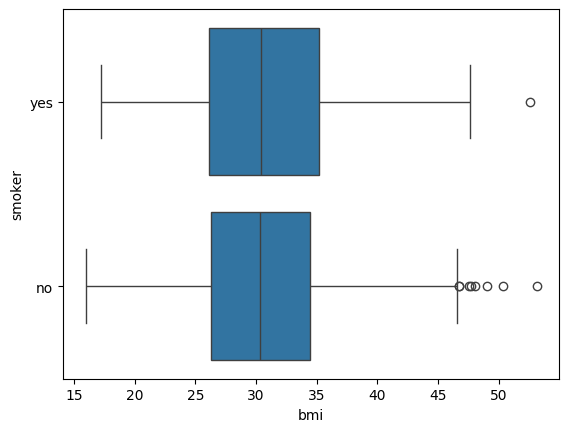

In [20]:
sns.boxplot(x=df["bmi"],y = df["smoker"],data = df)

<Axes: xlabel='children', ylabel='smoker'>

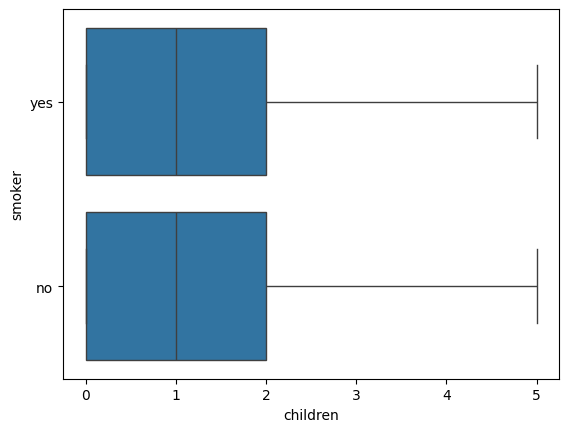

In [21]:
sns.boxplot(x=df["children"],y = df["smoker"],data = df)

<Axes: xlabel='charges', ylabel='smoker'>

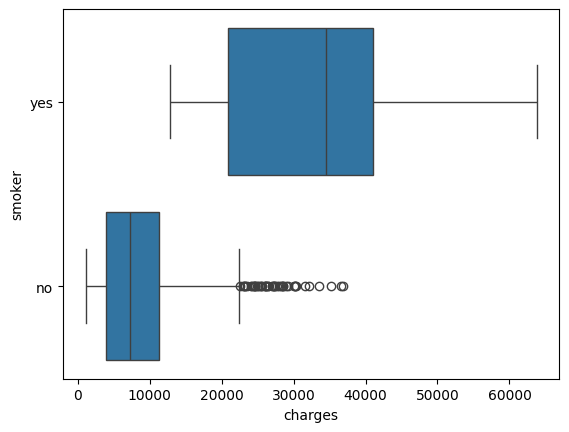

In [22]:
sns.boxplot(x=df["charges"],y = df["smoker"],data = df)

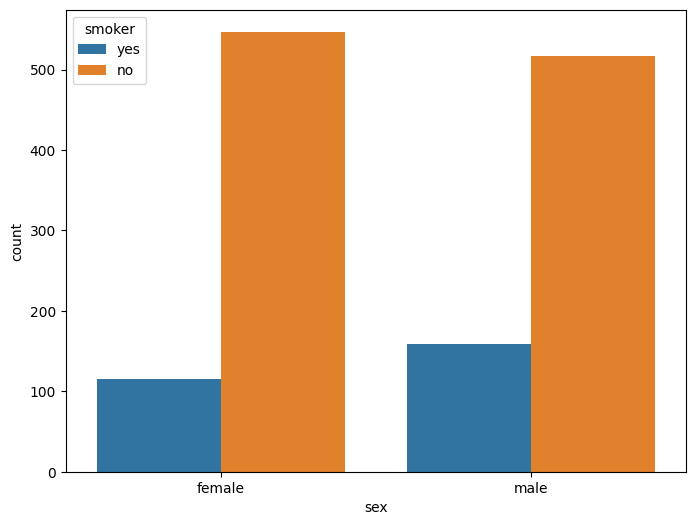

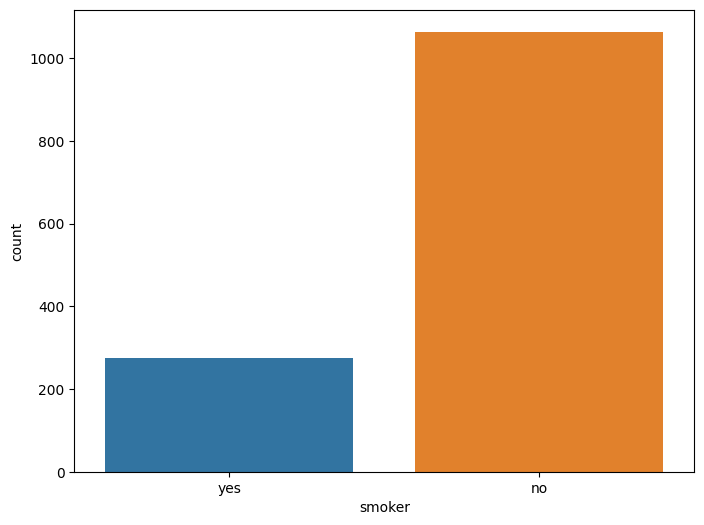

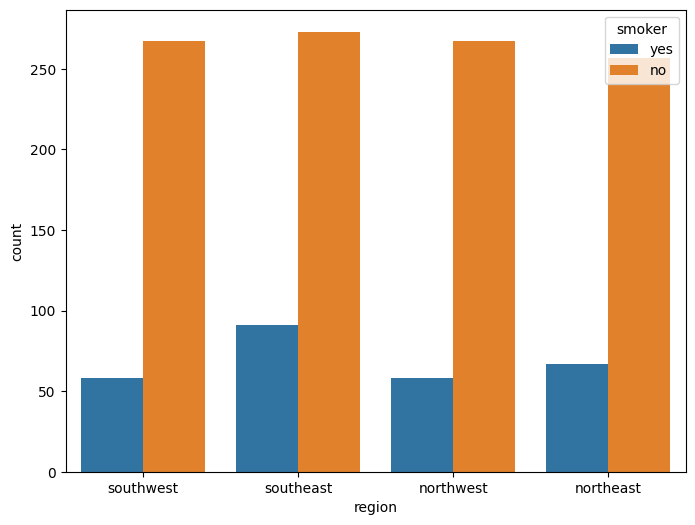

In [23]:
# cat_col vs target
for i in cat_col:
    plt.figure(figsize=(8,6))
    sns.countplot(x=i, hue="smoker",data=df)

<Axes: >

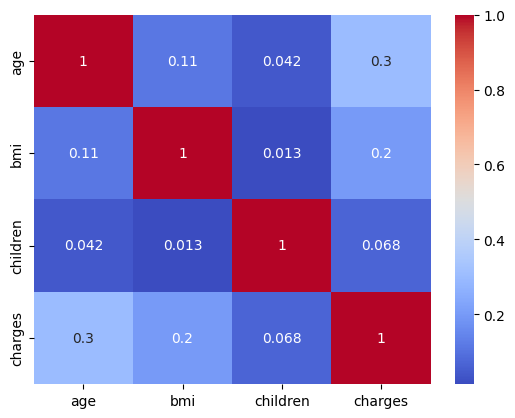

In [24]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')


In [25]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [26]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [27]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [28]:
# ENCODING
# 'sex', 'smoker', 'region'
data = df.copy()
data["smoker"] = data["smoker"].map({"yes":1, "no":0})

In [29]:
data['sex'] = data['sex'].map({'male':1,'female':0})
data['region'] = data['region'].map({'southwest':1,'southeast':2,'northwest':3,'northeast':4})

In [30]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520


In [31]:
X = data.drop('smoker',axis=1)
y = data['smoker']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
# Treating class imbalance in target col 'smoker' suing SMOTE

from imblearn.over_sampling import SMOTE

# smote clasa

smote = SMOTE(random_state=42)

# applying

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

y_train_smote.value_counts()




,count
smoker,
0,851
1,851


In [35]:
# Applying LOG Transformation in the cols 'Children' & 'Charges' to remove skewness

df['charges'].skew()

data['charges_log'] = np.log1p(data['charges'])


In [36]:
data['charges_log'].skew()

np.float64(-0.08981728740026822)

<Axes: xlabel='charges_log', ylabel='Count'>

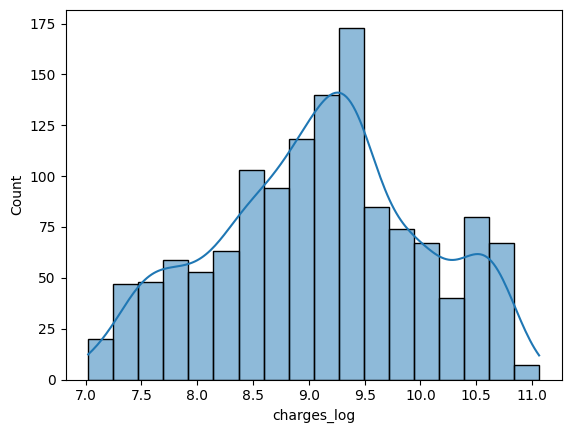

In [37]:
sns.histplot(data['charges_log'],kde=True)

In [38]:
# Hyper Parameter Tuning

from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_smote,y_train_smote)

AdaBoostClassifier(random_state=42)

In [39]:
y_pred = ada.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

accuracy_score(y_test,y_pred)

0.9776119402985075

In [41]:
precision_score(y_test,y_pred)

0.9016393442622951

In [42]:
recall_score(y_test,y_pred)

1.0

In [43]:
f1_score(y_test,y_pred)

0.9482758620689655

In [44]:
# Tuning

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],

             }



In [45]:
from sklearn.model_selection import RandomizedSearchCV

In [46]:
random_search = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)


In [47]:
random_search.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 1.0],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy')

In [48]:
print(random_search.best_params_)

{'n_estimators': 100, 'learning_rate': 1.0}


In [49]:
print(random_search.best_score_)

0.9671053993444886


In [50]:
# applying tuned params

best_ada = random_search.best_estimator_

In [51]:
AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

AdaBoostClassifier(learning_rate=0.5, n_estimators=100, random_state=42)

In [52]:
y_pred_tuned= best_ada.predict(X_test)

In [53]:
accuracy_score(y_test,y_pred_tuned)


0.9776119402985075

In [54]:
confusion_matrix(y_test,y_pred_tuned)

array([[207,   6],
       [  0,  55]])

In [55]:
import joblib
joblib.dump(best_ada, "adaboost_tuned.pkl")

['adaboost_tuned.pkl']